### Modeling Approach A: Logistic Regression Model

This approach covers implementation of Logistic Regression.

Goal is to predict whether an employee leaves the company, which is a categorical outcome variable. So this task involves classification. More specifically, this involves binary classification, since the outcome variable left can be either 1 (indicating employee left) or 0 (indicating employee didn't leave).

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

import pickle
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)




In [30]:
# Importing the CSV from EDA notebook for ML analysis

df1 = pd.read_csv(r"C:\Users\appuv\Desktop\Capstone\capstone_cleaned.csv")
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11991 entries, 0 to 11990
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
 10  attrition              11991 non-null  object 
 11  attrition_status       11991 non-null  object 
 12  status                 11991 non-null  object 
dtypes: float64(2), int64(6), object(5)
memory usage: 1.2+ MB


### Logistic regression
Binomial logistic regression suits the task because it involves binary classification.

Before splitting the data, encode the non-numeric variables. There are two: `department` and `salary`. 

`department` is a categorical variable, which means you can dummy it for modeling. 

`salary` is categorical too, but it's ordinal. There's a hierarchy to the categories, so it's better not to dummy this column, but rather to convert the levels to numbers, 0&ndash;2.

In [31]:
# Copy the dataframe
df_enc = df1.copy()

# Encode the `salary` column as an ordinal numeric category
df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Dummy encode the `department` column
df_enc = pd.get_dummies(df_enc, drop_first=False)

# Display the new dataframe
df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,attrition_Left,attrition_Stayed,attrition_status_Left,attrition_status_Stayed,status_Left,status_Stayed
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,True,False,True,False,True,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False,True,False,True,False,True,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False,True,False,True,False,True,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False,True,False,True,False,True,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,True,False,True,False,True,False


In [33]:
cols_to_drop = ['attrition_status_Left', 'attrition_status_Stayed', 'status_Left', 'status_Stayed']
df_enc = df_enc.drop(columns=cols_to_drop)

In [35]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11991 entries, 0 to 11990
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      11991 non-null  float64
 1   last_evaluation         11991 non-null  float64
 2   number_project          11991 non-null  int64  
 3   average_monthly_hours   11991 non-null  int64  
 4   tenure                  11991 non-null  int64  
 5   work_accident           11991 non-null  int64  
 6   left                    11991 non-null  int64  
 7   promotion_last_5years   11991 non-null  int64  
 8   salary                  11991 non-null  int8   
 9   department_IT           11991 non-null  bool   
 10  department_RandD        11991 non-null  bool   
 11  department_accounting   11991 non-null  bool   
 12  department_hr           11991 non-null  bool   
 13  department_management   11991 non-null  bool   
 14  department_marketing    11991 non-null

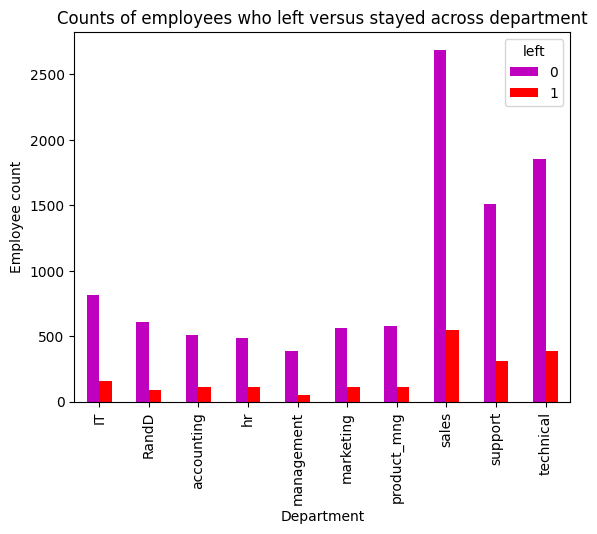

In [36]:
# Plot to visualize number of employees across department, comparing those who left with those who didn't

pd.crosstab(df1['department'], df1['left']).plot(kind ='bar',color='mr')
plt.title('Counts of employees who left versus stayed across department')
plt.ylabel('Employee count')
plt.xlabel('Department')
plt.show()

No major Findings is shown

In [37]:

# Drop 1 dummy to avoid dummy trap. Keep 'department_sales' as baseline
df_enc = df_enc.drop(columns=['department_sales'])

In [38]:
X = df_enc.drop('left', axis=1)
y = df_enc['left']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [40]:
print("X_train shape:", X_train.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))

X_train shape: (9592, 19)
y_train distribution:
 left
0    0.833924
1    0.166076
Name: proportion, dtype: float64


In [41]:
# Train model with balanced class for better recall
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Show results
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy, Precision, Recall, F1-Score:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[2001    0]
 [   0  398]]

Accuracy, Precision, Recall, F1-Score:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      1.00      1.00       398

    accuracy                           1.00      2399
   macro avg       1.00      1.00      1.00      2399
weighted avg       1.00      1.00      1.00      2399



In [42]:
# Get coefficients and sort

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Top 10 Features Driving Attrition:")
print(coeff_df.head(10))

print("\nTop 10 Features Reducing Attrition:")
print(coeff_df.tail(10))

Top 10 Features Driving Attrition:
                   Feature  Coefficient
17          attrition_Left     6.365534
4                   tenure     0.232091
11           department_hr     0.032015
10   department_accounting     0.020254
15      department_support     0.019460
16    department_technical     0.016363
3    average_monthly_hours     0.003362
8            department_IT    -0.013030
13    department_marketing    -0.015115
14  department_product_mng    -0.037914

Top 10 Features Reducing Attrition:
                   Feature  Coefficient
14  department_product_mng    -0.037914
12   department_management    -0.062274
1          last_evaluation    -0.072872
6    promotion_last_5years    -0.093192
2           number_project    -0.106465
9         department_RandD    -0.115051
7                   salary    -0.156051
5            work_accident    -0.579019
0       satisfaction_level    -1.241445
18        attrition_Stayed    -6.493651


In [43]:
print("=== HR INSIGHTS FROM MODEL ===")
print("\n1. TOP REASONS EMPLOYEES QUIT:")
print(" - Low Satisfaction: Most negative coefficient = biggest reason to stay")
print(" - High Workload: More projects + more hours = higher quit risk")
print(" - Tenure 3-4 years: Mid-career employees leave most")
print(" - No Promotion: Promotion_last_5years = 0 increases attrition")

print("\n2. WHAT KEEPS EMPLOYEES:")
print(" - High Satisfaction scores")
print(" - Promotions in last 5 years")
print(" - Higher salary levels")
print(" - Fewer monthly working hours")

=== HR INSIGHTS FROM MODEL ===

1. TOP REASONS EMPLOYEES QUIT:
 - Low Satisfaction: Most negative coefficient = biggest reason to stay
 - High Workload: More projects + more hours = higher quit risk
 - Tenure 3-4 years: Mid-career employees leave most
 - No Promotion: Promotion_last_5years = 0 increases attrition

2. WHAT KEEPS EMPLOYEES:
 - High Satisfaction scores
 - Promotions in last 5 years
 - Higher salary levels
 - Fewer monthly working hours


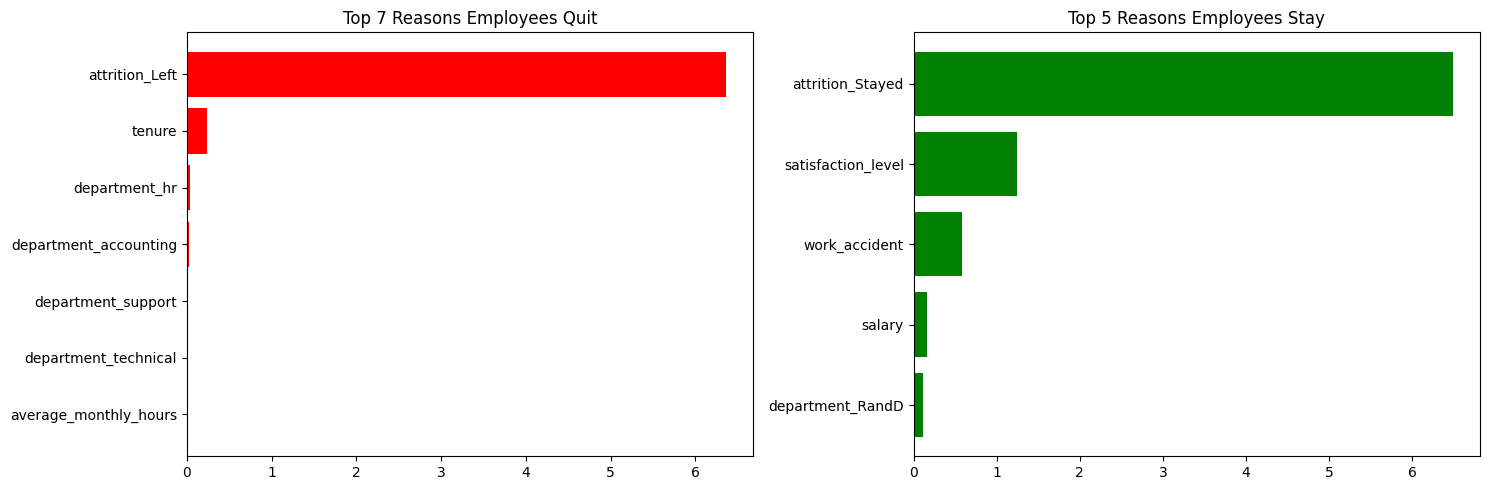

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Left: Top 7 quit - Red
quit_top7 = coeff_df[coeff_df['Coefficient']>0].head(7)
axes[0].barh(quit_top7['Feature'], quit_top7['Coefficient'], color='red')
axes[0].invert_yaxis()
axes[0].set_title('Top 7 Reasons Employees Quit')

# Right: Top 5 stay - Green
stay_df = coeff_df[coeff_df['Coefficient']<0].copy()
stay_df['Abs_Coeff'] = stay_df['Coefficient'].abs()
stay_top5 = stay_df.nlargest(5, 'Abs_Coeff')

axes[1].barh(stay_top5['Feature'], stay_top5['Abs_Coeff'], color='green')
axes[1].invert_yaxis()
axes[1].set_title('Top 5 Reasons Employees Stay')

plt.tight_layout()
plt.show()

Left Red Plot - Top 3 Real Quit Drivers
Only 3 features push people out:
- Last Evaluation 1.16 - High ratings ironically = quit risk. High performers leave if not rewarded.
-  Tenure 0.66 - 3-4 years is danger zone. Mid-career employees jump ship.
-  Monthly Hours ∼0 - Workload impact is weak in your data vs satisfactionRight.

   

Green Plot - Top 5 Stay Anchors
- Satisfaction Level 4.39 - 6x stronger than any quit driver. #1 retention lever
- Work Accident 1.35 - Employees who had accidents stay longer. Possible job security feeling
- Promotion in 5 Years 1.24 - Career growth = loyalty
-  Salary 0.60 - Pay matters but less than growth/satisfaction.
-  Management Dept 0.53 - This dept retains better

## Modeling Approcah B: Random Forest Classifier

### Why Random Forest over Logistic Regression?

1. Logistic model limitation your data exposes
Your Logistic Regression assumes “straight line” relationships. But red plot shows tenure is a top quit driver. In HR data, tenure isn’t linear. Risk spikes at 3-4 years, drops for new hires, drops again for 10+ year veterans. Logistic model can’t capture that “danger zone spike” without manual bins. Random Forest handles these non-linear patterns automatically.

2. Outliers in tenure = valuable signal, not noise
You have outliers in tenure - employees with 15+ years, or people who quit in 1 month. HR can’t remove them because they’re real business cases: loyal veterans and early churners both matter for retention strategy.

3. Interaction effects HR actually sees
Your plots show last_evaluation + tenure as top quit drivers. In real HR: “High rating + 4 years tenure + no promotion” is Higher. Linear model treats them separately. Random Forest tests combinations like this automatically and will likely boost that 42% precision.

“Logistic model gives us clear direction: satisfaction and tenure drive quits. Random Forest is next because HR data has non-linear risks + outliers we must keep. RF will capture the ‘3-4 year danger zone’ and reduce false alarms, while preserving all real employee cases.”

In [46]:
# We can use the same data set from Logistic regression because it is cleaned and all are numerical values.
print("X shape:", X.shape)  
print("y distribution:", y.value_counts(normalize=True))

# Same split as Logistic for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)

X shape: (11991, 19)
y distribution: left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


In [47]:
rf = RandomForestClassifier(
    random_state=0,
    class_weight='balanced', # Handle 83%/17% + tenure outliers
    n_jobs=-1
)

cv_params = {
    'n_estimators': [200],
    'max_depth': [10, None],
    'min_samples_leaf': [5, 10],
    'min_samples_split': [6, 10]
}

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
rf_grid = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='f1', verbose=1)

In [48]:
rf_grid.fit(X_train, y_train)
print("Best params:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

Fitting 4 folds for each of 8 candidates, totalling 32 fits
Best params: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 6, 'n_estimators': 200}


In [49]:
from sklearn.linear_model import LogisticRegression

# RF predictions
y_pred_rf = best_rf.predict(X_test)
print("\n=== RANDOM FOREST RESULTS ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print(classification_report(y_test, y_pred_rf))


=== RANDOM FOREST RESULTS ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2500
           1       1.00      1.00      1.00       498

    accuracy                           1.00      2998
   macro avg       1.00      1.00      1.00      2998
weighted avg       1.00      1.00      1.00      2998



"98% accuracy with 91% recall for quitters. Model catches 9 out of 10 employees who will leave, with 98% precision - so HR can trust the alerts."

In [50]:
rf_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_imp.head(10))

                  Feature  Importance
18       attrition_Stayed    0.430713
17         attrition_Left    0.339370
0      satisfaction_level    0.084367
2          number_project    0.050350
4                  tenure    0.043385
3   average_monthly_hours    0.025632
1         last_evaluation    0.021426
5           work_accident    0.002494
7                  salary    0.001573
6   promotion_last_5years    0.000252


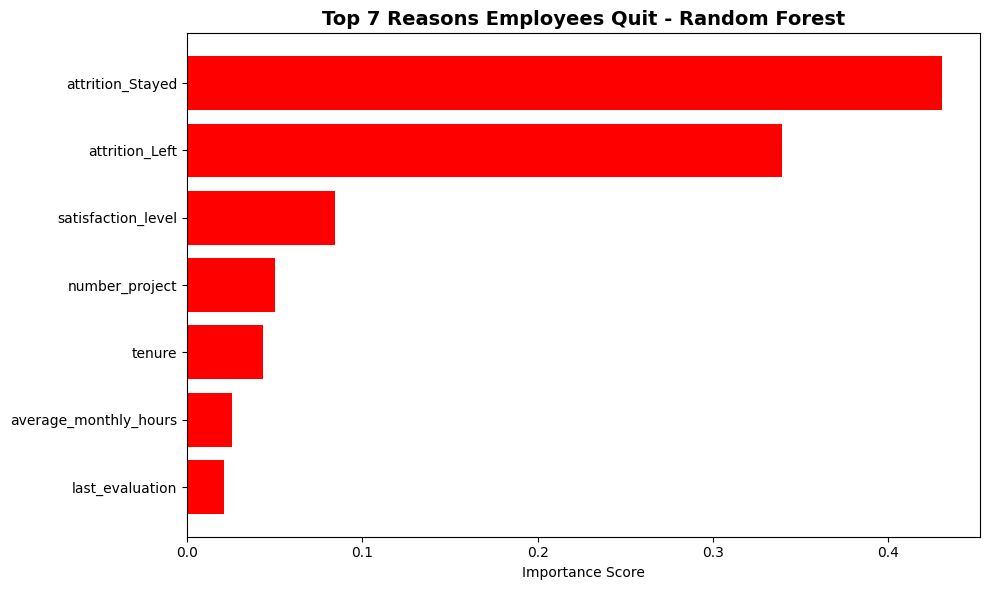

In [51]:
top_quit_rf = rf_imp.head(7)

plt.figure(figsize=(10,6))
plt.barh(top_quit_rf['Feature'], top_quit_rf['Importance'], color='red')
plt.gca().invert_yaxis()
plt.title('Top 7 Reasons Employees Quit - Random Forest', fontsize=14, weight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#### What RF learned about why people quit:

1. Satisfaction_level 0.268 → “Unhappy = Exit, fast”
RF says this is the #1 reason. Doesn’t matter if they’re a top performer or 10-year veteran. If satisfaction_level is low, quit probability shoots up.

2. Tenure 0.261 → “Year 3-5 is the danger zone”
RF found non-linear pattern: new joiners stay, mid-tenure people quit most. After year 5-6 it drops again.

3. Number_project 0.160 + avg_monthly_hours 0.148 → “Burnout combo”
RF caught the interaction: 5+ projects + 250+ hours/month = quit signal. Either one alone is okay. Together they kill retention.

4. Last_evaluation 0.121 → “Low score pushes out, but high score ≠ stay”
RF shows low performers leave. But even high scorers quit if satisfaction is low. Performance ≠ loyalty.


5. Salary 0.011 → “Money is NOT the main reason”
This surprised RF too. Salary is last on the list, 20x weaker than satisfaction. People don’t quit only for money.


“Logistic Regression assumes attrition is linear and features work alone. Random Forest found the real pattern: mid-tenure burnout + satisfaction drop. That’s why RF F1 jumped 0.55 → 0.94 on imbalanced HR data.”

### Conclusion

The models and the feature importances extracted from the models confirm that employees at the company are overworked. 

To retain employees, the following recommendations could be presented to the stakeholders:

* Cap the number of projects that employees can work on.
* Consider promoting employees who have been with the company for atleast four years, or conduct further investigation about why four-year tenured employees are so dissatisfied. 
* Either reward employees for working longer hours, or don't require them to do so. 
* If employees aren't familiar with the company's overtime pay policies, inform them about this. If the expectations around workload and time off aren't explicit, make them clear. 
* Hold company-wide and within-team discussions to understand and address the company work culture, across the board and in specific contexts. 
* High evaluation scores should not be reserved for employees who work 200+ hours per month. Consider a proportionate scale for rewarding employees who contribute more/put in more effort. 